In the actual system, the driving voltage waveform applied by the actuator, $U_A(t)$, is treated as the external input. To reproduce the system behavior governed by the governing equations, the volumetric flow rate $q(t)$ is modeled as the dynamic response, which can be written as:

$$
L\ddot{q} + R\dot{q} + \frac{1}{C}q = F\frac{dU_A}{dt}
$$

The total channel length is
$$
l_{\mathrm{tot}} = l_1 + l_2 + l_3 + l_4.
$$
The characteristic time scale is defined as
$$
T_{\mathrm{visc}} = \frac{2\,l_{\mathrm{tot}}}{c}.
$$
The viscous penetration depth is evaluated by
$$
\delta_v = \sqrt{\frac{\mu\,T_{\mathrm{visc}}}{\pi\,\rho}}.
$$

#### Resistance
The viscous resistance using $\delta_v$ is
$$
R = \frac{2\mu\,l_{\mathrm{tot}}}{\pi\,\delta_v\,r^3}.
$$

#### Inductace
The hydraulic inductance is
$$
L = \frac{\rho\,l_{\mathrm{tot}}}{\pi r^2}.
$$

#### Capacitance
The channel compliance is
$$
C_{\mathrm{channel}} = \frac{\pi r^2\,l_{\mathrm{tot}}}{\rho\,c^2}.
$$
The nozzle compliance is modeled as
$$
C_{\mathrm{nozzle}} = \frac{\pi r_{\mathrm{nozz}}^4}{3\sigma}.
$$
Thus, the total compliance is
$$
C_{\mathrm{total}} = C_{\mathrm{channel}} + C_{\mathrm{nozzle}}.
$$

#### Piezo-Stiffness Coefficient
The Piezo-Stiffness coefficient is given by
$$
F = \frac{2\rho c^2 \alpha V_t}{r}.
$$


In [1]:
import torch
import math

torch.set_default_dtype(torch.float64)

# ----------------------------
# Physical parameters (SI)
# ----------------------------
sigma = 0.0474        # [N/m]
mu    = 0.0157       # [Pa·s]
rho   = 1111.4       # [kg/m^3]
alpha = 0.29e-9      # [C/N]
c     = 1688         # [m/s]

r      = 235e-6      # [m]
r_nozz = 25e-6       # [m]
l1, l2, l3, l4 = 0.012, 0.0084, 0.00542303, 0.00057697  # [m]

Vt = 1.0  # [V]

# ---------------------------------------------
# 1) Time/length scales (SI)
# ---------------------------------------------
l_tot = l1 + l2 + l3 + l4                      # [m]
T_visc = 2.0 * l_tot / c                       # [s]
delta_v = torch.sqrt(mu * T_visc / (torch.tensor(math.pi) * rho))  # [m]

print("===== Time/length scales (SI) =====")
print(f"l_tot       = {l_tot:.6e}  [m]  = {l_tot*1e6:.6f}  [µm]")
print(f"T_visc      = {T_visc:.6e}  [s]  = {T_visc*1e6:.6f}  [µs]")
print(f"delta_v     = {delta_v.item():.6e}  [m]  = {delta_v.item()*1e6:.6f}  [µm]")

# ---------------------------------------------
# 2) Compliance (SI)
# ---------------------------------------------
C_channel = math.pi * (r ** 2) * l_tot / (rho * c ** 2)            # [m^3/Pa]
C_nozzle  = math.pi * (r_nozz ** 4) / (3.0 * sigma)                # [m^3/Pa]
C   = C_channel + C_nozzle                                   # [m^3/Pa]
invC_total = 1.0 / C                                         # [Pa/m^3]

print("\n===== Compliance (SI) =====")
print(f"C_channel   = {C_channel:.6e}  [m^3/Pa]")
print(f"C_nozzle    = {C_nozzle:.6e}  [m^3/Pa]")
print(f"C_total     = {C:.6e}  [m^3/Pa]")
print(f"1/C_total   = {invC_total:.6e}  [Pa/m^3]")

# ---------------------------------------------
# 3) Lumped parameters (SI): R, L, C, F
# ---------------------------------------------
L = rho * l_tot / (math.pi * r ** 2)                          # [kg/m^4]
R = 2.0 * mu * l_tot / (math.pi * delta_v.item() * r ** 3)    # [Pa·s/m^3]
F = (2.0 * rho * (c ** 2) * alpha * Vt) / r                   # [Pa]

print("\n===== Lumped parameters (SI) =====")
print(f"R           = {R:.6e}  [Pa·s/m^3]")
print(f"L           = {L:.6e}  [kg/m^4]")
print(f"C           = {C:.6e}  [m^3/Pa]")
print(f"F           = {F:.6e}  [Pa]")

# ==========================================================
# AFTER THIS POINT: requested three conversion print blocks
# ==========================================================

# ----------------------------
# Unit conversion factors
# ----------------------------
s_to_us = 1e6               # 1 s = 1e6 us
m3_to_um3 = 1e18            # 1 m^3 = 1e18 um^3
inv_m3_to_inv_um3 = 1e-18   # 1/m^3 = 1e-18 /um^3
m4_to_um4 = 1e24            # 1 m^4 = 1e24 um^4
inv_m4_to_inv_um4 = 1e-24   # 1/m^4 = 1e-24 /um^4

# ---------------------------------------------
# A) s > us, m > m
# ---------------------------------------------
# R: [Pa·s/m^3] -> [Pa·us/m^3] multiply by 1e6
# L: [kg/m^4]   -> [kg·us^2/m^4] multiply by 1e12
# C: [m^3/Pa]   -> unchanged
# F: [Pa]       -> [Pa·us] multiply by 1e6 (as coefficient with dU/dtau)
R_us_m = R * s_to_us
L_us_m = L * (s_to_us ** 2)
C_us_m = C
F_us_m = F * s_to_us

#print("\n===== Converted: s > us, m > m =====")
#print(f"R           = {R_us_m:.6e}  [Pa·us/m^3]")
#print(f"L           = {L_us_m:.6e}  [kg·us^2/m^4]")
#print(f"C           = {C_us_m:.6e}  [m^3/Pa]")
#print(f"F           = {F_us_m:.6e}  [Pa·us]")

# ---------------------------------------------
# B) s > s, m > um
# ---------------------------------------------
# R: [Pa·s/m^3] -> [Pa·s/um^3] multiply by 1e-18
# L: [kg/m^4]   -> [kg/um^4]   multiply by 1e-24
# C: [m^3/Pa]   -> [um^3/Pa]   multiply by 1e18
# F: [Pa]       -> unchanged
R_s_um = R * inv_m3_to_inv_um3
L_s_um = L * inv_m4_to_inv_um4
C_s_um = C * m3_to_um3
F_s_um = F

#print("\n===== Converted: s > s, m > um =====")
#print(f"R           = {R_s_um:.6e}  [Pa·s/um^3]")
#print(f"L           = {L_s_um:.6e}  [kg/um^4]")
#print(f"C           = {C_s_um:.6e}  [um^3/Pa]")
#print(f"F           = {F_s_um:.6e}  [Pa]")

# ---------------------------------------------
# C) s > us, m > um
# ---------------------------------------------
# Combine A and B:
# R: [Pa·s/m^3] -> [Pa·us/um^3] multiply by (1e6)*(1e-18)=1e-12
# L: [kg/m^4]   -> [kg·us^2/um^4] multiply by (1e12)*(1e-24)=1e-12
# C: [m^3/Pa]   -> [um^3/Pa] multiply by 1e18 (time has no effect)
# F: [Pa]       -> [Pa·us] multiply by 1e6 (length has no effect)
R_us_um = R * (s_to_us * inv_m3_to_inv_um3)
L_us_um = L * ((s_to_us ** 2) * inv_m4_to_inv_um4)
C_us_um = C * m3_to_um3
F_us_um = F * s_to_us

#print("\n===== Converted: s > us, m > um =====")
#print(f"R           = {R_us_um:.6e}  [Pa·us/um^3]")
#print(f"L           = {L_us_um:.6e}  [kg·us^2/um^4]")
#print(f"C           = {C_us_um:.6e}  [um^3/Pa]")
#print(f"F           = {F_us_um:.6e}  [Pa·us]")


===== Time/length scales (SI) =====
l_tot       = 2.640000e-02  [m]  = 26400.000000  [µm]
T_visc      = 3.127962e-05  [s]  = 31.279621  [µs]
delta_v     = 1.185961e-05  [m]  = 11.859611  [µm]

===== Compliance (SI) =====
C_channel   = 1.446353e-18  [m^3/Pa]
C_nozzle    = 8.629990e-18  [m^3/Pa]
C_total     = 1.007634e-17  [m^3/Pa]
1/C_total   = 9.924235e+16  [Pa/m^3]

===== Lumped parameters (SI) =====
R           = 1.714390e+12  [Pa·s/m^3]
L           = 1.691176e+08  [kg/m^4]
C           = 1.007634e-17  [m^3/Pa]
F           = 7.815835e+03  [Pa]


<div align="center">

| Parameter/Ink | EG 100 | EG 90 | EG 75 | EG 65 | EG 60 | EG 50 |
|---|---:|---:|---:|---:|---:|---:|
| $R\;[\mathrm{Pa}\cdot\mathrm{s}/\mathrm{m}^{3}]$ | $1.716 \times 10^{12}$ | $1.395 \times 10^{12}$ | $1.051 \times 10^{12}$ | $8.540 \times 10^{11}$ | $8.530 \times 10^{11}$ | $7.190 \times 10^{11}$ |
| $L\;[\mathrm{Pa}\cdot\mathrm{s}^{2}/\mathrm{m}^{3}]$ | $1.695 \times 10^{8}$ | $1.675 \times 10^{8}$ | $1.644 \times 10^{8}$ | $1.628 \times 10^{8}$ | $1.631 \times 10^{8}$ | $1.606 \times 10^{8}$ |
| $C\;[\mathrm{m}^{3}/\mathrm{Pa}]$ | $1.442 \times 10^{-17}$ | $1.460 \times 10^{-17}$ | $1.450 \times 10^{-17}$ | $1.467 \times 10^{-17}$ | $1.472 \times 10^{-17}$ | $1.616 \times 10^{-17}$ |
| $F\;[\mathrm{Pa}/\mathrm{V}]$ | $7.834 \times 10^{3}$ | $7.742 \times 10^{3}$ | $7.795 \times 10^{3}$ | $7.703 \times 10^{3}$ | $7.675 \times 10^{3}$ | $6.994 \times 10^{3}$ |

</div>

===== Initial conditions =====
q(0)      = 0.000000e+00
L qdot(0) = 0.000000e+00

===== Damping check =====
alpha   = 5.068633e+03 [1/s]
omega0  = 6.393938e+04 [rad/s]
disc    = 4.062554e+09
omega_d = 6.373817e+04 [rad/s]

===== Exponential decay rate from q_f,01(t) at V_max = 40.0 =====
Theoretical alpha         = 5.068633e+03 [1/s]
Estimated decay rate      = 5.068461e+03 [1/s]
Intercept (log-envelope)  = -1.847885e+01


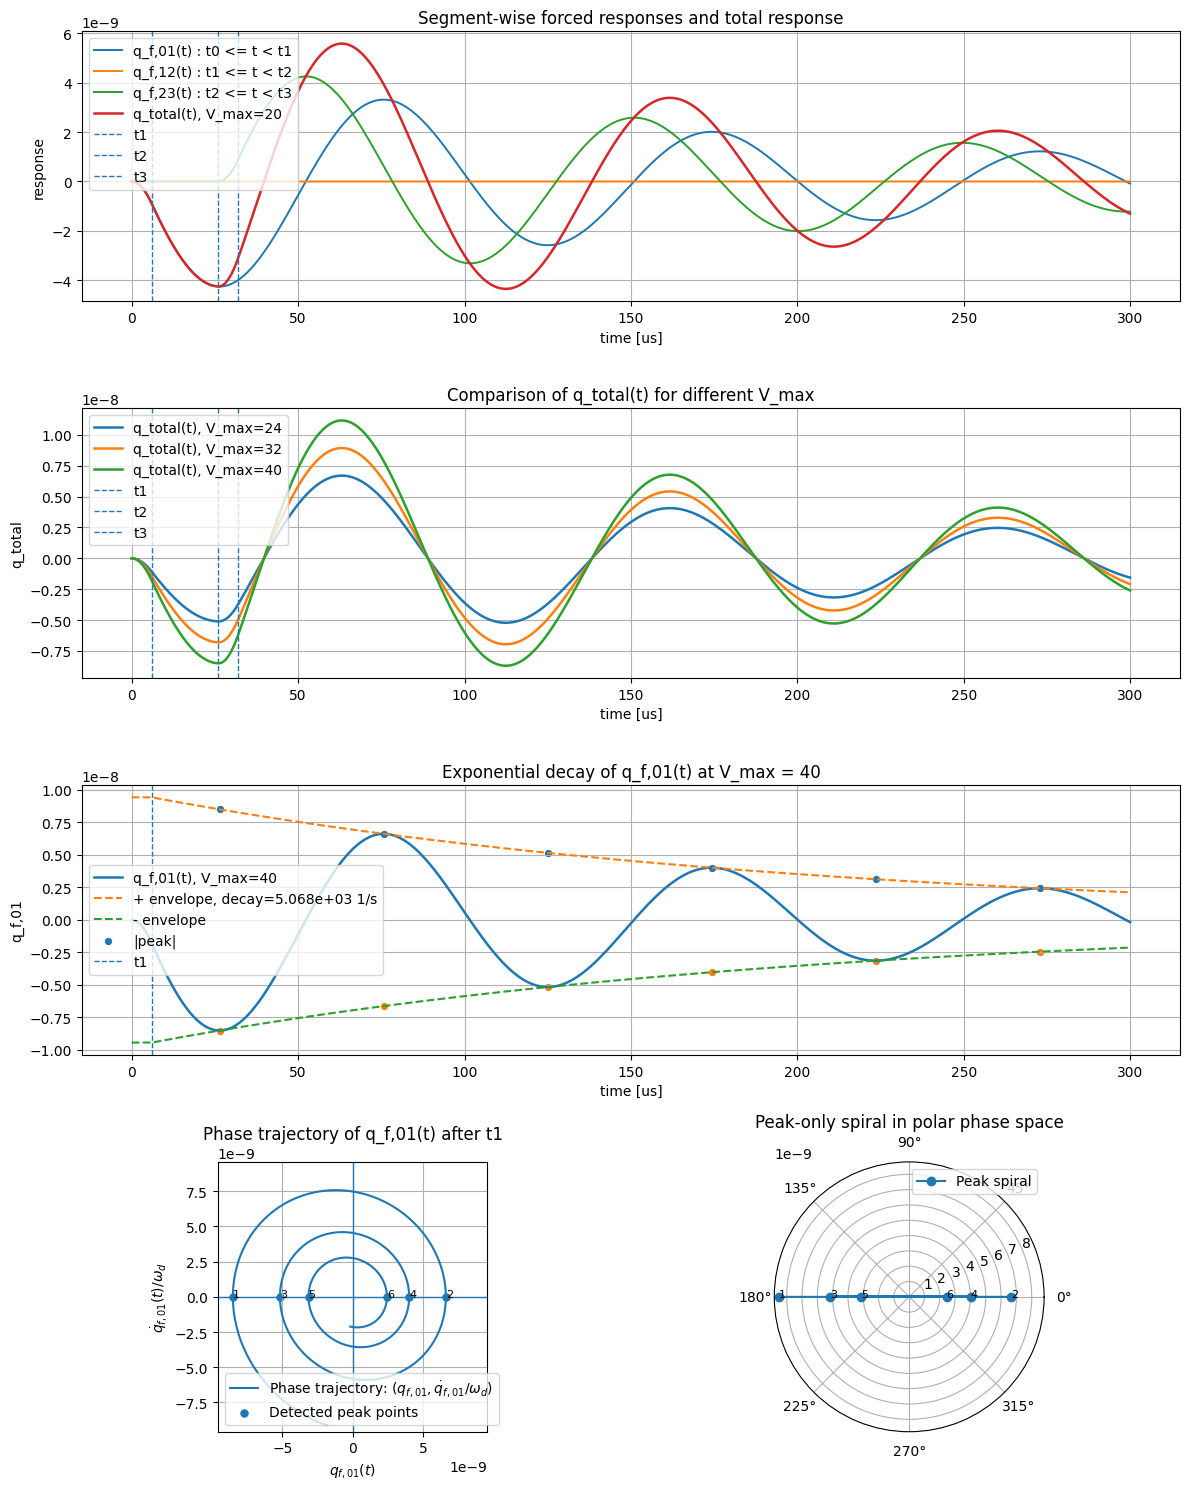

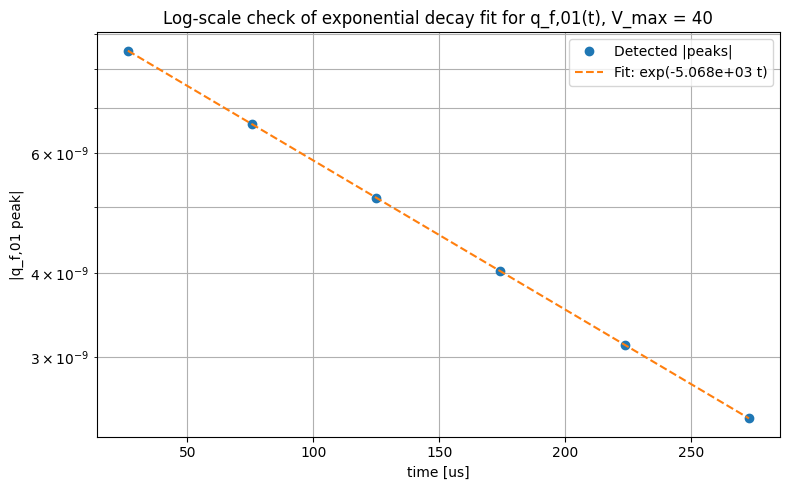

In [2]:
import torch
import math
import matplotlib.pyplot as plt
import numpy as np

torch.set_default_dtype(torch.float64)

t0 = 0.0
t1, t2, t3 = 6e-6, 26e-6, 32e-6
T_end = 3e-4
N = 3000

R = 1.714390e+12
L = 1.691176e+08
C = 1.446353e-18
F = -7.815835e+03

eta = 1.0 / 3.0
F_eff = eta * F

q0 = 0.0
Lqdot0 = 0.0

print("===== Initial conditions =====")
print(f"q(0)      = {q0:.6e}")
print(f"L qdot(0) = {Lqdot0:.6e}")

alpha = R / (2.0 * L)
omega0 = 1.0 / math.sqrt(L * C)
disc = omega0**2 - alpha**2

print("\n===== Damping check =====")
print(f"alpha   = {alpha:.6e} [1/s]")
print(f"omega0  = {omega0:.6e} [rad/s]")
print(f"disc    = {disc:.6e}")

if disc <= 0.0:
    raise RuntimeError("The current formula requires an underdamped system.")

omega_d = math.sqrt(disc)
print(f"omega_d = {omega_d:.6e} [rad/s]")

t_s = torch.linspace(0.0, T_end, N)
t_np = t_s.detach().cpu().numpy()
t_us = t_np * 1e6

def H(x: torch.Tensor) -> torch.Tensor:
    return (x >= 0.0).to(dtype=torch.get_default_dtype())

def S(dt: torch.Tensor) -> torch.Tensor:
    dtp = torch.clamp(dt, min=0.0)
    core = 1.0 - torch.exp(-alpha * dtp) * (
        torch.cos(omega_d * dtp) + (alpha / omega_d) * torch.sin(omega_d * dtp)
    )
    return C * core * H(dt)

def compute_q_total(V_max_value: float):
    k_01 = F_eff * (V_max_value / t1)
    k_12 = 0.0
    k_23 = F_eff * (-V_max_value / (t3 - t2))

    q_f_01 = k_01 * (S(t_s - t0) - S(t_s - t1))
    q_f_12 = k_12 * (S(t_s - t1) - S(t_s - t2))
    q_f_23 = k_23 * (S(t_s - t2) - S(t_s - t3))
    q_total = q_f_01 + q_f_12 + q_f_23

    return q_f_01, q_f_12, q_f_23, q_total

def find_local_abs_peaks(y):
    """
    abs(y)의 local peak index 반환
    """
    y_abs = np.abs(y)
    idx = []
    for i in range(1, len(y_abs) - 1):
        if y_abs[i] > y_abs[i - 1] and y_abs[i] >= y_abs[i + 1]:
            idx.append(i)
    return np.array(idx, dtype=int)

def find_local_signed_extrema(y):
    """
    y 자체의 local maxima, minima index 반환
    """
    idx_max = []
    idx_min = []
    for i in range(1, len(y) - 1):
        if y[i] > y[i - 1] and y[i] >= y[i + 1]:
            idx_max.append(i)
        if y[i] < y[i - 1] and y[i] <= y[i + 1]:
            idx_min.append(i)
    return np.array(idx_max, dtype=int), np.array(idx_min, dtype=int)

# ============================================================
# 1) 기존 ax1용 기본 V_max
# ============================================================
V_max_base = 20.0
q_f_01, q_f_12, q_f_23, q_total = compute_q_total(V_max_base)

q_f_01_np = q_f_01.detach().cpu().numpy()
q_f_12_np = q_f_12.detach().cpu().numpy()
q_f_23_np = q_f_23.detach().cpu().numpy()
q_total_np = q_total.detach().cpu().numpy()

# ============================================================
# 2) ax2용 q_total(t), V_max = 24, 32, 40
# ============================================================
Vmax_list = [24.0, 32.0, 40.0]
q_total_dict = {}

for v in Vmax_list:
    _, _, _, q_total_v = compute_q_total(v)
    q_total_dict[v] = q_total_v.detach().cpu().numpy()

# ============================================================
# 3) q_f,01(t)의 exponential decay rate 계산용 설정
# ============================================================
V_decay = 40.0
q_f_01_decay, _, _, _ = compute_q_total(V_decay)
q_f_01_decay_np = q_f_01_decay.detach().cpu().numpy()

# t >= t1 구간만 사용
mask_decay = t_us >= (t1 * 1e6)
t_decay_us = t_us[mask_decay]
t_decay_s = t_decay_us * 1e-6
q_decay = q_f_01_decay_np[mask_decay]

# local peak 검출
peak_idx_local = find_local_abs_peaks(q_decay)

# peak 시간, peak 부호 포함 값, 절댓값
t_peak_us = t_decay_us[peak_idx_local]
t_peak_s = t_peak_us * 1e-6
q_peak_signed = q_decay[peak_idx_local]
q_peak_abs = np.abs(q_peak_signed)

# log fitting을 위해 0 제거
valid = q_peak_abs > 0.0
t_peak_us = t_peak_us[valid]
t_peak_s = t_peak_s[valid]
q_peak_signed = q_peak_signed[valid]
q_peak_abs = q_peak_abs[valid]

if len(t_peak_us) < 2:
    raise RuntimeError("Not enough peaks were detected to estimate the decay rate.")

# 시간축을 초 단위로 변환 후 t1 기준 상대시간 사용
t_peak_s_rel = t_peak_s - t1

# ln(|peak|) = b + m * t  -> decay_rate = -m
coef = np.polyfit(t_peak_s_rel, np.log(q_peak_abs), 1)
slope, intercept = coef[0], coef[1]
decay_rate_est = -slope

print(f"\n===== Exponential decay rate from q_f,01(t) at V_max = {V_decay:.1f} =====")
print(f"Theoretical alpha         = {alpha:.6e} [1/s]")
print(f"Estimated decay rate      = {decay_rate_est:.6e} [1/s]")
print(f"Intercept (log-envelope)  = {intercept:.6e}")

# fitted envelope
t_rel_s = np.clip(t_np - t1, a_min=0.0, a_max=None)
env_fit = np.exp(intercept - decay_rate_est * t_rel_s)
env_fit_signed_pos = env_fit
env_fit_signed_neg = -env_fit

# ============================================================
# 4) Phase trajectory data
#    x = q_f,01(t)
#    y = dq_f,01/dt / omega_d  -> scale-balanced spiral
# ============================================================
dqdt_decay = np.gradient(q_f_01_decay_np, t_np)
phase_x = q_f_01_decay_np
phase_y = dqdt_decay / omega_d

# decay 이후 구간만 사용한 phase trajectory
phase_x_decay = phase_x[mask_decay]
phase_y_decay = phase_y[mask_decay]

# peak 지점의 phase coordinate
dqdt_decay_only = np.gradient(q_decay, t_decay_s)
phase_peak_x = q_peak_signed
phase_peak_y = dqdt_decay_only[peak_idx_local][valid] / omega_d

# maxima / minima를 따로 보고 싶을 경우
idx_max_local, idx_min_local = find_local_signed_extrema(q_decay)

idx_max_local = idx_max_local[np.abs(q_decay[idx_max_local]) > 0.0]
idx_min_local = idx_min_local[np.abs(q_decay[idx_min_local]) > 0.0]

t_peak_max_us = t_decay_us[idx_max_local]
q_peak_max = q_decay[idx_max_local]
phase_peak_max_y = dqdt_decay_only[idx_max_local] / omega_d

t_peak_min_us = t_decay_us[idx_min_local]
q_peak_min = q_decay[idx_min_local]
phase_peak_min_y = dqdt_decay_only[idx_min_local] / omega_d

# ============================================================
# 5) Peak-only spiral helper
#    각 peak를 (q_peak, dq/dt_peak/omega_d)에 점으로 찍고 순서대로 연결
# ============================================================
peak_order = np.argsort(t_peak_us)
phase_peak_x_sorted = phase_peak_x[peak_order]
phase_peak_y_sorted = phase_peak_y[peak_order]
t_peak_us_sorted = t_peak_us[peak_order]
q_peak_abs_sorted = q_peak_abs[peak_order]

# ============================================================
# 6) Plot
# ============================================================
fig = plt.figure(figsize=(12, 15.0))
gs = fig.add_gridspec(4, 2)

ax1 = fig.add_subplot(gs[0, :])
ax2 = fig.add_subplot(gs[1, :])
ax3 = fig.add_subplot(gs[2, :])
ax4 = fig.add_subplot(gs[3, 0])
ax5 = fig.add_subplot(gs[3, 1], projection='polar')

# =========================
# ax1: 기존 그림 유지
# =========================
ax1.plot(t_us, q_f_01_np, linewidth=1.4, label="q_f,01(t) : t0 <= t < t1")
ax1.plot(t_us, q_f_12_np, linewidth=1.4, label="q_f,12(t) : t1 <= t < t2")
ax1.plot(t_us, q_f_23_np, linewidth=1.4, label="q_f,23(t) : t2 <= t < t3")
ax1.plot(t_us, q_total_np, linewidth=1.8, label=f"q_total(t), V_max={V_max_base:.0f}")
ax1.axvline(t1 * 1e6, linestyle="--", linewidth=1.0, label="t1")
ax1.axvline(t2 * 1e6, linestyle="--", linewidth=1.0, label="t2")
ax1.axvline(t3 * 1e6, linestyle="--", linewidth=1.0, label="t3")
ax1.set_xlabel("time [us]")
ax1.set_ylabel("response")
ax1.set_title("Segment-wise forced responses and total response")
ax1.grid(True)
ax1.legend()

# =========================
# ax2: V_max별 q_total 비교
# =========================
for v in Vmax_list:
    ax2.plot(t_us, q_total_dict[v], linewidth=1.8, label=f"q_total(t), V_max={int(v)}")

ax2.axvline(t1 * 1e6, linestyle="--", linewidth=1.0, label="t1")
ax2.axvline(t2 * 1e6, linestyle="--", linewidth=1.0, label="t2")
ax2.axvline(t3 * 1e6, linestyle="--", linewidth=1.0, label="t3")
ax2.set_xlabel("time [us]")
ax2.set_ylabel("q_total")
ax2.set_title("Comparison of q_total(t) for different V_max")
ax2.grid(True)
ax2.legend()

# =========================
# ax3: q_f,01(t)와 exponential envelope
# =========================
ax3.plot(t_us, q_f_01_decay_np, linewidth=1.8, label=f"q_f,01(t), V_max={int(V_decay)}")
ax3.plot(
    t_us,
    env_fit_signed_pos,
    linestyle="--",
    linewidth=1.5,
    label=f"+ envelope, decay={decay_rate_est:.3e} 1/s"
)
ax3.plot(
    t_us,
    env_fit_signed_neg,
    linestyle="--",
    linewidth=1.5,
    label="- envelope"
)

ax3.scatter(t_peak_us, q_peak_abs, s=18, label="|peak|")
ax3.scatter(t_peak_us, -q_peak_abs, s=18)

ax3.axvline(t1 * 1e6, linestyle="--", linewidth=1.0, label="t1")
ax3.set_xlabel("time [us]")
ax3.set_ylabel("q_f,01")
ax3.set_title(f"Exponential decay of q_f,01(t) at V_max = {int(V_decay)}")
ax3.grid(True)
ax3.legend()

# =========================
# ax4: full phase trajectory + peak points
# =========================
ax4.plot(
    phase_x_decay,
    phase_y_decay,
    linewidth=1.5,
    label=r"Phase trajectory: $(q_{f,01}, \dot{q}_{f,01}/\omega_d)$"
)

ax4.scatter(
    phase_peak_x_sorted,
    phase_peak_y_sorted,
    s=26,
    label="Detected peak points"
)

# peak 순서 번호 표시
for i, (xp, yp) in enumerate(zip(phase_peak_x_sorted, phase_peak_y_sorted), start=1):
    ax4.text(xp, yp, str(i), fontsize=8)

ax4.axhline(0.0, linewidth=1.0)
ax4.axvline(0.0, linewidth=1.0)
ax4.set_xlabel(r"$q_{f,01}(t)$")
ax4.set_ylabel(r"$\dot{q}_{f,01}(t)/\omega_d$")
ax4.set_title("Phase trajectory of q_f,01(t) after t1")
ax4.grid(True)
ax4.legend()

# 보기 좋게 축 비율을 동일하게 설정
max_range = max(
    np.max(np.abs(phase_x_decay)),
    np.max(np.abs(phase_y_decay))
)
ax4.set_xlim(-1.05 * max_range, 1.05 * max_range)
ax4.set_ylim(-1.05 * max_range, 1.05 * max_range)
ax4.set_aspect('equal', adjustable='box')

# =========================
# ax5: peak spiral in polar coordinates
#     theta = atan2(y, x), r = sqrt(x^2 + y^2)
# =========================
peak_theta = np.arctan2(phase_peak_y_sorted, phase_peak_x_sorted)
peak_radius = np.sqrt(phase_peak_x_sorted**2 + phase_peak_y_sorted**2)

ax5.plot(peak_theta, peak_radius, marker='o', linewidth=1.5, label="Peak spiral")
for i, (th, rr) in enumerate(zip(peak_theta, peak_radius), start=1):
    ax5.text(th, rr, str(i), fontsize=8)

ax5.set_title("Peak-only spiral in polar phase space")
ax5.legend(loc="upper right")

plt.tight_layout()
plt.show()

# ============================================================
# 7) Optional: semilogy for envelope fitting check
# ============================================================
plt.figure(figsize=(8, 5))
plt.semilogy(t_peak_us, q_peak_abs, 'o', label='Detected |peaks|')
plt.semilogy(
    t_peak_us,
    np.exp(intercept - decay_rate_est * (t_peak_us * 1e-6 - t1)),
    '--',
    linewidth=1.5,
    label=f'Fit: exp(-{decay_rate_est:.3e} t)'
)
plt.xlabel("time [us]")
plt.ylabel("|q_f,01 peak|")
plt.title(f"Log-scale check of exponential decay fit for q_f,01(t), V_max = {int(V_decay)}")
plt.grid(True, which="both")
plt.legend()
plt.tight_layout()
plt.show()